In [27]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
sys.path.append("../")
from diabnet.apply_ensemble import Predictor
from diabnet.data import get_feature_names
from diabnet.ensemble import Ensemble

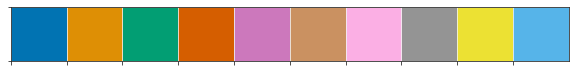

In [29]:
colors = sns.color_palette("colorblind")
sns.palplot(colors)
sns.set_style("whitegrid")
sns.set_style("ticks",{'axes.grid': True,'grid.color': '.95', 'grid.linestyle': '-'})

In [30]:
fn = "../datasets/visits_sp_changed_test_positivo_1000_random_0.csv"
def dataset_test_first_diag(fn):
    df = pd.read_csv(fn)
    # seleciona as amostras negativas e agrupa por id pegando a MAIOR idade
    neg  = df[df.T2D == 0][['id','AGE']].groupby('id').max()
    # seleciona as amostras positivas e agrupa por id pegando a MENOR idade
    pos  = df[df.T2D == 1][['id','AGE']].groupby('id').min()
    dtmp = neg.join(pos, lsuffix='_neg', rsuffix='_pos')
    # filtra somente pacientes que a idade negativa < idade positiva
    dtmp = dtmp[dtmp.AGE_neg < dtmp.AGE_pos]
    tmp = pd.concat([pd.DataFrame({'AGE':dtmp.AGE_neg}),pd.DataFrame({'AGE':dtmp.AGE_pos})])
    tmp = tmp.reset_index()
    # Eu odeio a API do pandas!!!
    df = df.merge(tmp, on=['id','AGE'], how="inner")
    return df

df_first = dataset_test_first_diag(fn)
df_unique = pd.read_csv("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv")

In [31]:
def plot(df, samples): 
    plt.figure(figsize=(16,16))
    color_boxplot = sns.color_palette("cool", n_colors=20)
    plt.subplots_adjust(hspace=0.4, wspace=0.2)
    for i in range(len(samples)):
        ax1=plt.subplot(4, 4, i+1)
        id = samples[i]
        features = df[c].iloc[id].values
        label = df["T2D"].iloc[id]
        age = features[-4]; age
        probs_life = pred.patient_life(features, samples_per_model=1)
        color_boxplot = sns.color_palette("cool", n_colors=20)
        plt.title(f"patient - id: {df['id'].iloc[id]}\n(age: {age}, diagnostic: {'P' if label==1 else 'N'})")
        sns.boxplot(x=[i for i in probs_life[1]], y=probs_life[0], showfliers=False, palette=[color_boxplot[int(np.median(a)*20)] for a in probs_life[0]]);
        plt.xlabel("age")
        plt.ylim(0,1);

In [32]:
ensemble = Ensemble('../diabnet/models/model-6-soft-label-age-positives-2500-dropout0-bn-decay-flood-hyperopt-batch256-lc1-20200831')
c = get_feature_names("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv", BMI=False, sex=True, parents_diagnostics=True)
pred = Predictor(ensemble, c, "../datasets/visits_sp_unique_test_positivo_1000_random_0_negatives_older60.csv")

../diabnet/models/model-6-soft-label-age-positives-2500-dropout0-bn-decay-flood-hyperopt-batch256-lc1-20200831
NEGATIVE FILE ../datasets/visits_sp_unique_test_positivo_1000_random_0_negatives_older60.csv


In [33]:
# true negatives are people older than 60 and negative
neg_life = pred.negatives_life(samples_per_model=1)

# Estudo de amostras  

Nesse notebook avaliaremos C tipos com N indivíduos para entender o comportamento do classificador. Os tipos são:

- Idosos e positivos.
- Idosos e negativos.
- Jovens e positivos.
- Jovens e negativos.

In [34]:
N = 16

## 1 - Idosos positivos 

*primeiro diagnóstico após 60 anos de idade

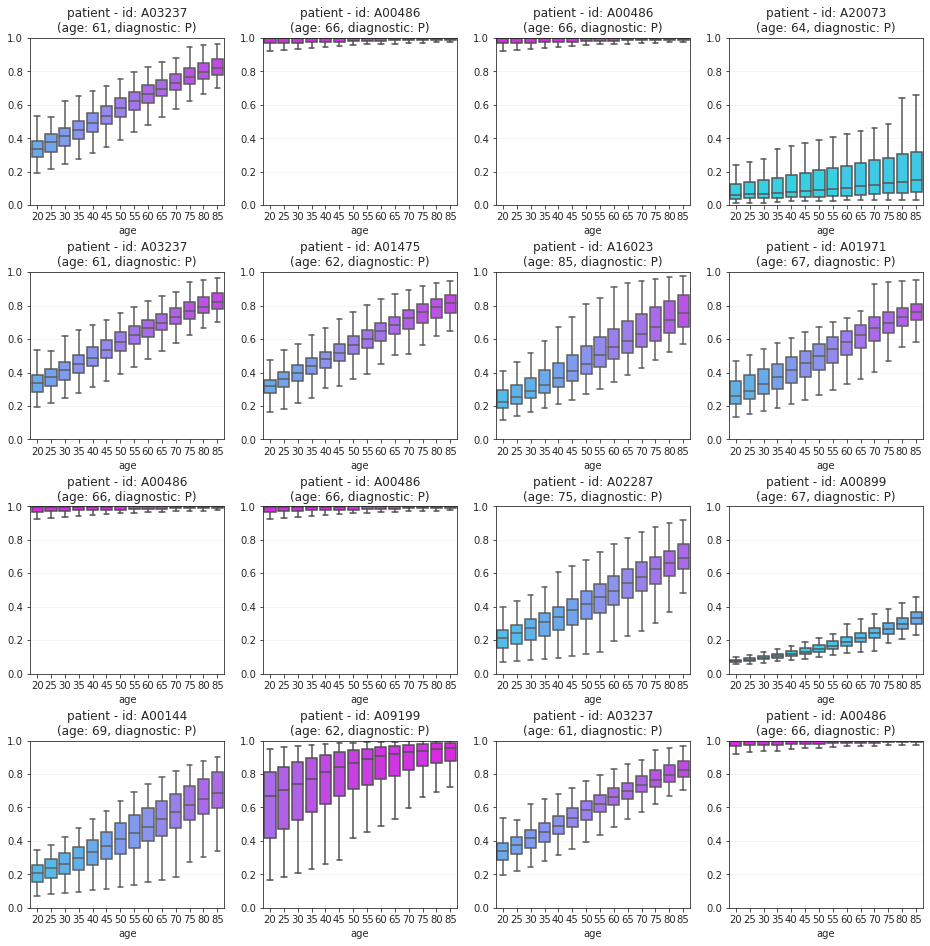

In [35]:
# individuos idosos e positivos
df = df_first
samples = np.random.choice(df[(df.T2D==1)&(df.AGE>60)].index, N);samples
plot(df, samples)

## 2 - Idosos negativos

*negativos com mais de 60 anos

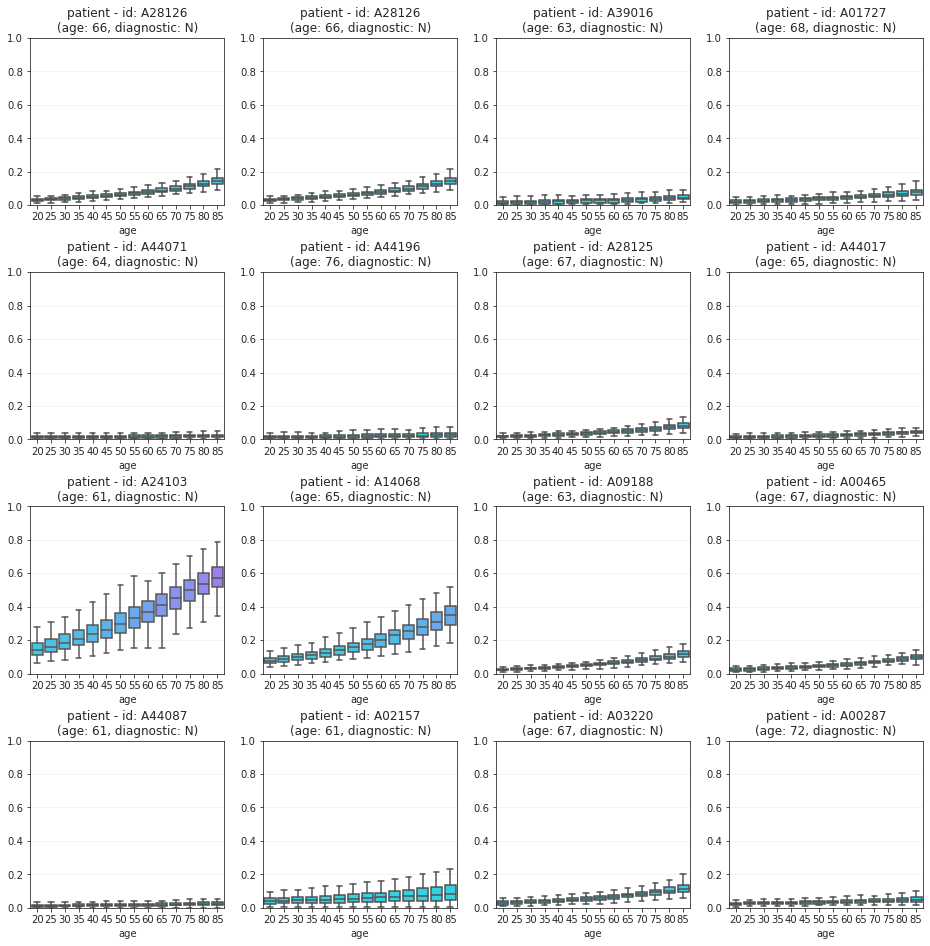

In [36]:
# individuos idosos e positivos
df = df_unique
samples = np.random.choice(df[(df.T2D==0)&(df.AGE>60)].index, N);samples
plot(df, samples)

## 3 - Jovens positivos

*positivos com menos de 40 anos

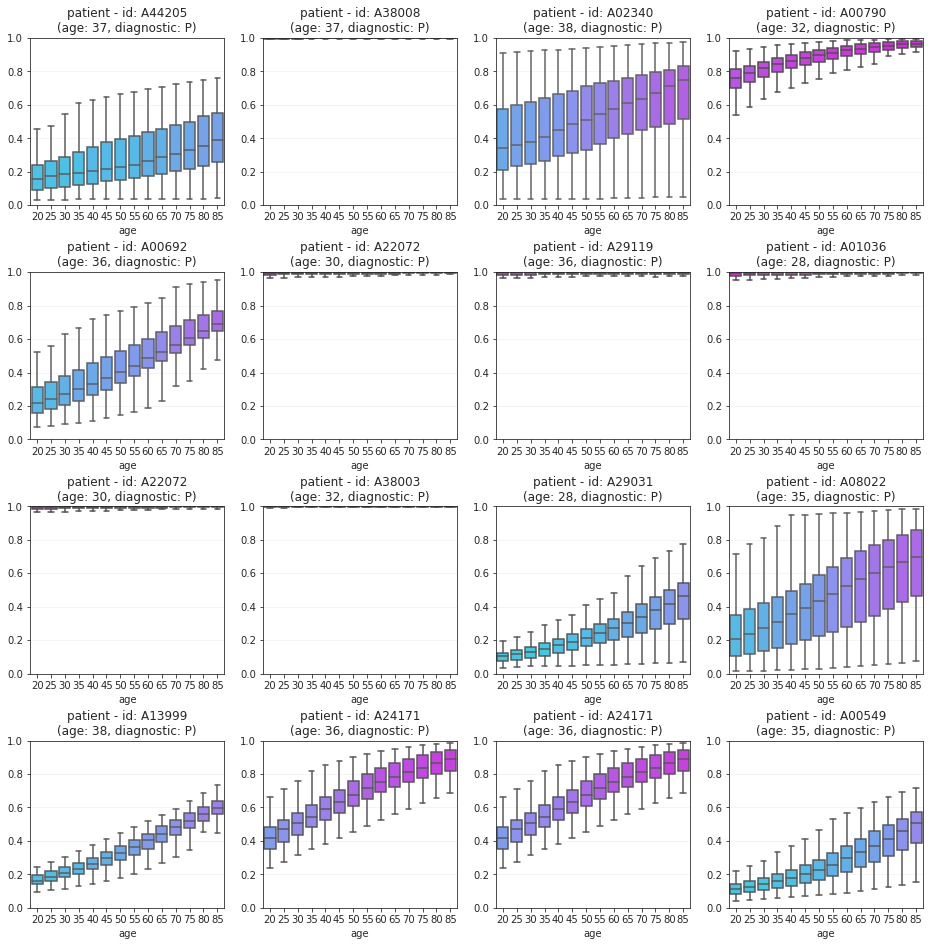

In [37]:
# individuos idosos e positivos
df = df_first
samples = np.random.choice(df[(df.T2D==1)&(df.AGE<40)].index, N);samples
plot(df, samples)

## 4 - Jovens negativos

*negativos com menos de 40 anos

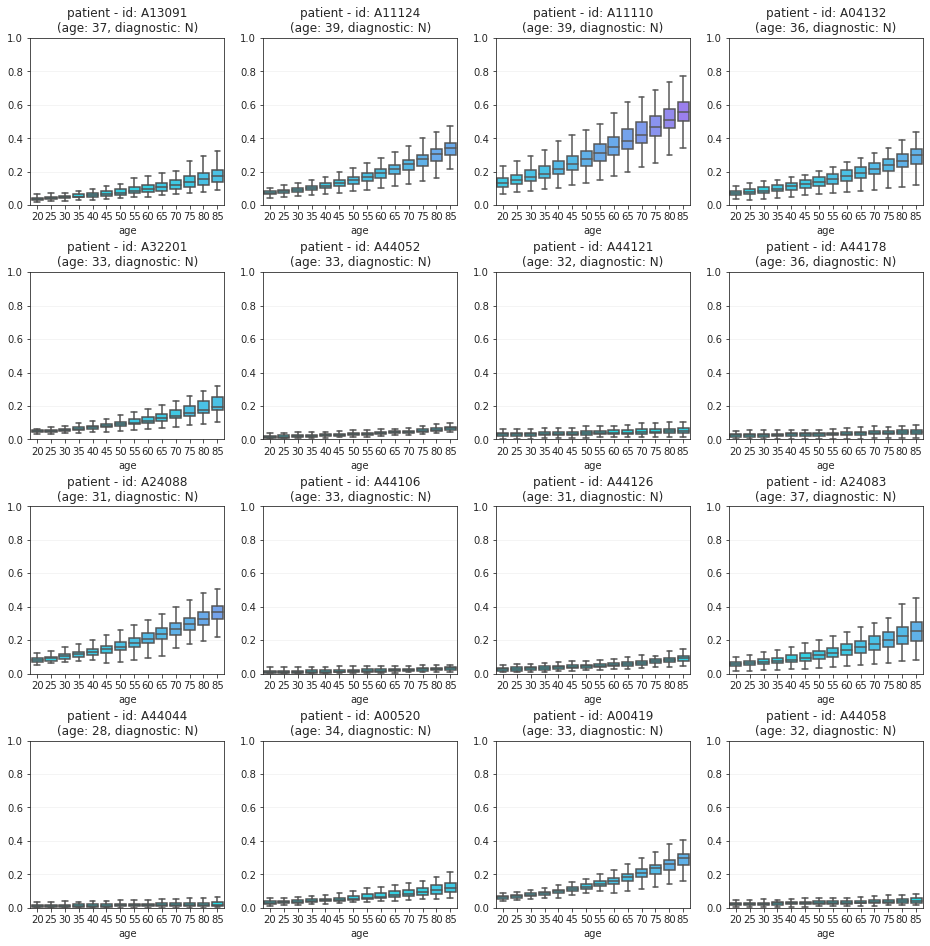

In [38]:
# individuos idosos e positivos
df = df_unique
samples = np.random.choice(df[(df.T2D==0)&(df.AGE<40)].index, N);samples
plot(df, samples)